<a href="https://colab.research.google.com/github/chelsietao/Penguin_classifier/blob/main/penguin_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
import pandas as pd
df = pd.read_csv('palmer-penguins.csv')

In [34]:
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [35]:
# 資料集大小 (行數, 欄位數)
print(df.shape)


(344, 8)


In [36]:
# 欄位名稱清單
print(df.columns.to_list())


['species', 'island', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex', 'year']


In [37]:
# 各欄位的資料型態與缺漏值統計
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
 7   year               344 non-null    int64  
dtypes: float64(4), int64(1), object(3)
memory usage: 21.6+ KB
None


In [38]:
# 每種企鵝的數量統計
print(df['species'].value_counts())

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64


In [39]:
# 每種企鵝的數量統計
print(df['species'].value_counts())

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64


In [40]:
original_count = len(df)
original_count

344

In [41]:
# axis=1 代表「橫向（逐列，Row-wise）
# axis=0（通常是預設值）：直向運算
missing_data = df[df.isnull().any(axis=1)]
missing_data

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN,2007
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN,2007
10,Adelie,Torgersen,37.8,17.1,186.0,3300.0,NaN,2007
11,Adelie,Torgersen,37.8,17.3,180.0,3700.0,NaN,2007
47,Adelie,Dream,37.5,18.9,179.0,2975.0,NaN,2007
178,Gentoo,Biscoe,44.5,14.3,216.0,4100.0,NaN,2007
218,Gentoo,Biscoe,46.2,14.4,214.0,4650.0,NaN,2008
256,Gentoo,Biscoe,47.3,13.8,216.0,4725.0,NaN,2009
268,Gentoo,Biscoe,44.5,15.7,217.0,4875.0,NaN,2009


In [42]:
df_clean = df.dropna()
clean_count = len(df_clean)
clean_count

333

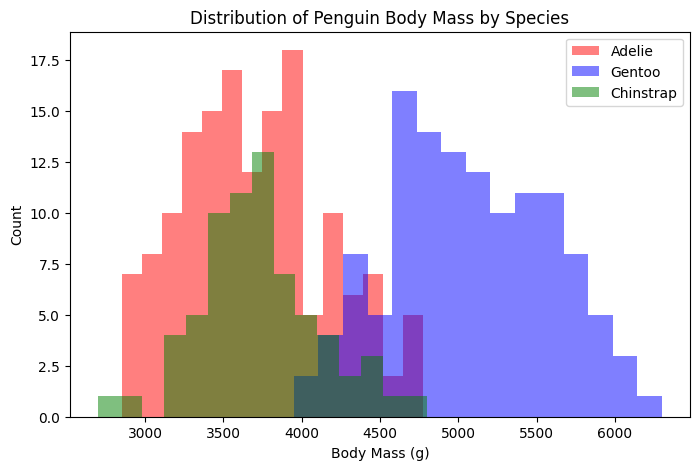

In [43]:
import pandas as pd
import matplotlib.pyplot as plt

# .dropna(subset=[...])只關心體重和品種，只要這兩個欄位沒有空值就好
df = df.dropna(subset=['body_mass_g','species'])

# 在畫圖前，先開一張長寬比例為 8:5 的空白畫布
plt.figure(figsize=(8,5))

# .unique() 它會去掃描 species 這個欄位，把裡面所有「不重複」的值挑出來變成一個陣列
# （在這裡會抓出 ['Adelie', 'Gentoo', 'Chinstrap']）
# 好處是：你不需要手動打字輸入企鵝的名字，如果未來資料庫多了一種新企鵝，程式碼也不用改
species_list = df['species'].unique()
colors = ['red', 'blue', 'green']

# zip(清單A, 清單B)：它會像拉鍊一樣，把兩個清單的元素一對一「扣」在一起
# 第 1 圈：species 拿到 'Adelie'，color 拿到 'red'
# 第 2 圈：species 拿到 'Gentoo'，color 拿到 'blue'
# 這樣我們就可以在同一個迴圈裡，同時處理品種和它對應的顏色

# 先找出符合目前品種的所有橫列 df[df['species'] == species]
# 然後立刻在後面加上 ['body_mass_g']
# 只把這些企鵝的「體重」數字抽出來存入 mass_data

# plt.hist(...)：專門用來畫直方圖的函數
# bins=15：把體重的範圍（例如 3000g 到 6000g）切成 15 個「垃圾桶/區間」。體重落在哪個區間，那個區間的柱子就會長高。
# alpha=0.5 控制「透明度」（0 是一半透明，1 是完全不透明）
# 如果不設定透明，先畫的企鵝體重柱子，會被後畫的企鵝完全遮住
# label=species：幫這個顏色的柱子貼上標籤，告訴系統這是哪種企鵝，留給後面的圖例使用

for species, color in zip(species_list, colors):
  mass_data = df[df['species'] == species]['body_mass_g']
  plt.hist(mass_data, bins=15, alpha=0.5, color=color, label=species)


# plt.legend()：把剛剛設定的 label 顯示在圖表角落（圖例），讓看圖的人知道紅色、藍色、綠色分別代表什麼企鵝

plt.xlabel('Body Mass (g)')
plt.ylabel('Count')
plt.title('Distribution of Penguin Body Mass by Species')
plt.legend()
plt.show()

## Section 2: Data Preparation and Processing

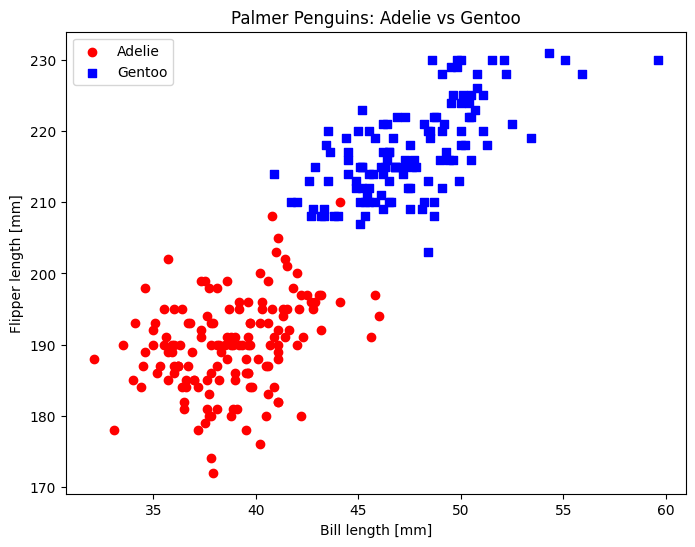

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. load data
# read_csv：把 CSV 檔案讀取進來，變成一個叫做 df (DataFrame) 的表格物件
df = pd.read_csv('palmer-penguins.csv')

# 2. clean and filter data (remove missing values)
# dropna：Drop Not a Number。把有「空值 (缺漏資料)」的橫列刪除
# subset=[...]：指定「只要這三個欄位裡面有空值，就把那隻企鵝的資料整筆刪除」，避免訓練時發生錯誤
df = df.dropna(subset=['species', 'bill_length_mm', 'flipper_length_mm'])

# keep adelir and gentoo penguins
# isin([...])：這是個篩選條件。告訴 pandas：「我只要品種 (species) 是 Adelie 或是 Gentoo 的企鵝」
# 把篩選後的新表格命名為 df_subset
df_subset = df[df['species'].isin(['Adelie', 'Gentoo'])]

# 3. extract labels(y) and features(X)
# set Adelie label to 0 and Gentoo to 1
# # np.where(條件, 符合時給什麼, 不符合時給什麼)：這是一個超好用的「陣列版 IF 判斷式」
y = np.where(df_subset['species'] == 'Adelie', 0, 1)

# extract bill length and flipper length
# 從表格中提取出「鳥喙長度」和「鰭狀肢長度」這兩欄
# .values：這個語法會把 pandas 的表格，瞬間脫殼變成 NumPy 的純數字矩陣 (2D Array)。我們把它存成變數 X（大寫 X 在數學中通常代表矩陣）
X = df_subset[['bill_length_mm', 'flipper_length_mm']].values

# 4. plot the scallerplot
# plt.scatter(X座標, Y座標, ...)：用來畫散佈圖
# X[y == 0, 0] 是 NumPy 陣列特有的切片語法 (Slicing)：X[ 哪幾列 , 哪幾欄 ]
# y == 0 (哪幾列)：找出所有標籤是 0 (Adelie 企鵝) 的橫列。
# 0 (哪幾欄)：取出第 0 欄的特徵（也就是 鳥喙長度 bill_length_mm）
# X[y == 0, 1]：同理，取出 Adelie 企鵝的第 1 欄特徵（鰭狀肢長度 flipper_length_mm）
# marker='o'：把 Adelie 畫成圓圈圈
# marker='s'：把 Gentoo 畫成正方形 (Square)
plt.figure(figsize=(8,6))
plt.scatter(X[y == 0,0], X[y == 0,1], color='red', marker='o', label='Adelie')
plt.scatter(X[y == 1,0], X[y == 1,1], color='blue', marker='s', label='Gentoo')

# plt.xlabel, ylabel, legend, title 只是幫圖片加上 X軸標籤、Y軸標籤、圖例和標題，然後用 plt.show() 把圖片顯示出來
plt.xlabel('Bill length [mm]')
plt.ylabel('Flipper length [mm]')
plt.legend(loc='upper left')
plt.title('Palmer Penguins: Adelie vs Gentoo')
plt.show()

## Section 1: Object-Oriented Implementation of the Perceptron

In [45]:
import numpy as np

# __init__：初始化設定 (定義學習規則)
# eta (學習率)：每次模型猜錯時，要「修正多大的幅度」 。通常介於 0.0 到 1.0 之間
# n_iter (訓練回合數)：規定這個模型要看完整份資料「多少遍」 (Epochs)
# random_state (隨機種子)：給定一個固定的數字，確保每次程式跑出來的隨機初始權重都一樣，方便我們重現結果
class Perceptron:
  def __init__(self, eta=0.01, n_iter=50, random_state=1):
    self.eta = eta # learning rate
    self.n_iter = n_iter # number of training epochs
    self.random_state = random_state # random seed

# fit：模型訓練 (大腦學習的過程)
# 創造一個隨機數產生器 rgen
# self.random_state: 隨機種子 (Random Seed) 因為電腦的隨機其實是「偽隨機」，只要給定相同的種子數字（例如 1），每次產生的隨機數序列就會一模一樣 。這在機器學習非常重要，這樣你和別人（或你明天再跑一次）跑出來的結果才會完全相同，方便除錯和比較。
# rgen.normal(...)：從「常態分佈 (Normal Distribution)」中隨機抽出數字
# loc=0.0：常態分佈的中心點（平均值）設在 0
# scale=0.01：標準差設為 0.01。這代表抽出來的數字會非常接近 0（例如 0.003, -0.008），但又不會剛好是 0
# X.shape[1] 代表資料的「欄位數量 (特徵數量)
# self.b_：Bias（偏差值）可以想像成模型決策的「門檻值」
# np.float_(0.)：將偏差值初始設定為浮點數的 0.0
# self.errors_：這是一個空的 Python 陣列 (List) 等一下模型開始訓練時，每跑完一個回合 (Epoch)，我們就會把「這回合猜錯了幾隻企鵝」的數字塞進這個陣列裡 。最後我們畫出的「訓練折線圖」，就是拿這本記錄本裡的數字來畫的
  def fit(self, X, y):
    rgen = np.random.RandomState(self.random_state)
    self.w_ = rgen.normal(loc=0.0, scale=0.01, size=X.shape[1])
    self.b_ = np.float64(0.)
    self.errors_ = []

    for _ in range(self.n_iter): # 外層迴圈：決定要訓練幾回合
      errors = 0
      for xi, target in zip(X,y): # 內層迴圈 (zip(X,y))：把特徵 xi 和正確答案 target 綁在一起，一筆一筆餵給模型
        update = self.eta * (target - self.predict(xi)) # 計算更新值 # 如果猜對了：target 和 predict 一樣，相減為 0，update 就會是 0（不調整）# 如果猜錯了：相減會是 1 或 -1，乘上學習率 eta，模型就知道該往哪個方向修正
        self.w_ += update * xi
        self.b_ += update #把剛剛算出來的 update 加回權重和偏差裡，讓模型變得更聰明一點
        errors += int(update != 0.0)
      self.errors_.append(errors)
    return self

# net_input：計算淨輸入
# np.dot(X, self.w_)：算的是特徵向量與權重向量的「內積 (Dot product)」 。算完後再加上偏差值 self.b_ 。這相當於數學公式：z = w^T x + b
  def net_input(self, X):
    return np.dot(X, self.w_) + self.b_

# predict：做出最終預測
# np.where(...)：這是一個單位階躍函數 (Unit step function)
# 如果前面算出來的淨輸入 >= 0.0，就預測為 1（例如 Gentoo 企鵝），否則預測為 0（例如 Adelie 企鵝）
  def predict(self, X):
    return np.where(self.net_input(X) >= 0.0, 1, 0)

## Section 3: Visualization and Decision Regions

In [46]:
# from matplotlib.colors import ...：引入繪圖套件，特別是 ListedColormap 用來建立我們自訂的顏色地圖

from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
import numpy as np
# Import numpy here for np.unique, np.meshgrid, np.arange, np.array, np.ravel, np.reshape

# # def plot_decision_regions(...)：這是主函式，需要吃進特徵資料 X、標籤 y、訓練好的模型 classifier，以及一個網格解析度 resolution（數字越小，畫出來的邊界越平滑）
def plot_decision_regions(X, y, classifier, resolution=0.02):
  markers = ('o', 's', '^', 'v', '<')
  colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
  cmap = ListedColormap(colors[:len(np.unique(y))]) # 透過 ListedColormap 建立一個顏色地圖 (colormap)
  # np.unique(y) 找出資料中有幾種不同的類別，並自動從顏色清單中截取對應數量的顏色來使用

  # 建立密密麻麻的「網格畫布」
  # x1_min, x1_max ...：這兩行透過尋找你資料特徵 1 和特徵 2 的最小值與最大值，並加上/減去 1 來保留一點邊界留白，從而決定畫布的範圍
  # np.meshgrid(...)：透過 NumPy 的 meshgrid 函式，利用剛剛算出的範圍和解析度，生成一對二維的網格陣列 xx1 和 xx2
  # 想像它在畫布上打上了密密麻麻的座標網格
  # np.arange 全名是 "array range" 按照你指定的規則，產生一串等差的數字陣列
  # 基本語法 np.arange(start, stop, step)
  # start (起始值)：從哪個數字開始（包含這個數字）。如果沒寫，預設是 0。
  # stop (結束值)：到哪個數字結束（不包含這個數字）
  # step (間距/步長)：每個數字之間的距離。如果沒寫，預設是 1。
  # Python 內建的 range() 只能產生「整數」，但 np.arange 可以產生「小數 (浮點數)」的間距
  # 這裡的 resolution 在函式開頭被設定為 0.02。
  # 所以這行程式碼的意思是：「從特徵 1 的最小值 (x1_min) 開始，一路往上加 0.02，直到特徵 1 的最大值 (x1_max) 為止，給我一長串的數字陣列。」
  x1_min, x1_max = X[:,0].min() - 1, X[:,0].max() + 1
  x2_min, x2_max = X[:,1].min() - 1, X[:,1].max() + 1
  xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution), np.arange(x2_min, x2_max, resolution))

  # .ravel() (攤平) 前面的程式碼已經產生了二維的網格點陣列 xx1 和 xx2。ravel() 的作用是把這兩塊二維的網格「攤平」成一條長長的一維陣列
  # np.array([...]) (組合)：把攤平後的特徵 1 (xx1) 和特徵 2 (xx2) 上下疊起來，變成一個擁有兩列 (rows) 的二維陣列
  # .T (矩陣轉置) 因為機器學習模型習慣吃「每一列 (row) 代表一筆資料，每一欄 (column) 代表一個特徵」的格式 。轉置之後，每一列就完美代表畫布上的一個座標點 [特徵1數值, 特徵2數值]
  # classifier.predict(...)：把這成千上萬個網格座標點全部丟進訓練好的模型裡預測classifier.predict(...)：把這成千上萬個網格座標點全部丟進訓練好的模型裡預測
  # 模型會吐回一個長長的一維陣列，裡面裝滿了每個點的預測標籤（例如一堆 0 和 1），並存入變數 lab 裡
  # 因為剛剛經過 predict 吐出來的 lab 是一長條的「一維陣列」，但我們的畫布是一塊「二維」的網格
  # reshape(xx1.shape)：把這條長長的陣列，重新折疊回原本 xx1 的二維長寬形狀 。確保每一個預測出來的類別標籤，都能精準對應回畫布上原來的 X 與 Y 座標位置
  lab = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
  lab = lab.reshape(xx1.shape)

  # plt.contourf：這是 Matplotlib 用來畫「填滿的等高線圖 (Filled Contour Plot)」的函式
  # 它會根據每個座標 (xx1, xx2) 對應的高度/數值（在這裡就是我們的預測標籤 lab），將相鄰且數值相同的區域連起來，並塗滿顏色 。這就是模型「決策邊界」成型的瞬間。
  # cmap=cmap：套用你稍早在程式碼中設定好的客製化顏色地圖
  # alpha=0.3：將背景顏色的透明度設定為 30%
  plt.contourf(xx1, xx2, lab, alpha=0.3, cmap=cmap)

  # np.unique(y)：這會掃描你的標籤陣列 y（裡面可能有一大堆 0 和 1），然後回傳裡面「不重複」的類別
  # enumerate(...)：在跑迴圈時，當下的元素值 cl（例如現在正在處理類別 0），給你一個計數器索引 idx（例如這是第 0 圈）
  # y == cl：這會產生一個跟資料筆數一樣長的 True / False 陣列（Mask 遮罩）。如果該筆資料的真實標籤等於目前的類別 cl，就是 True，反之為 False。
  # x = X[y == cl, 0]：把它想像成一個過濾器。我們叫 NumPy 只把 y == cl 為 True 的那些列 (rows) 挑出來，然後 , 0 代表我們只要拿出第 0 個欄位（也就是特徵 1，當作 X 軸座標）
  # y = X[y == cl, 1]：同理，把符合該類別的資料挑出來，拿到第 1 個欄位（也就是特徵 2，當作 Y 軸座標）。
  # 「把屬於目前這個類別 (cl) 的所有點的 X 跟 Y 座標一口氣全部抓出來畫在圖上」
  # alpha=0.8：透明度設為 0.8（稍微有一點點透明），這樣就算點重疊，或是為了看清楚背後的等高線顏色，視覺上也會比較舒服
  # c=colors[idx]：根據現在跑到的迴圈次數 idx，去你稍早定義的 colors 清單裡面拿對應的顏色。例如第 0 圈就拿紅色，第 1 圈拿藍色
  # marker=markers[idx]：跟顏色一樣，去 markers 清單拿形狀。例如第 0 圈畫圈圈 ('o')，第 1 圈畫方塊 ('s')
  # label=f'Class {cl}'：給這群點一個名字，之後畫圖例 (Legend) 的時候會顯示出來。這裡使用了 Python 的 f-string 語法，如果 cl 是 0，字串就會變成 'Class 0'
  # edgecolor='black'：幫每一個資料點的邊緣畫上一圈黑框。這是一個很實用的小技巧，因為如果資料點的顏色剛好跟背景預測區塊的顏色一樣，沒有這圈黑框，點就會隱形在背景裡了
  for idx, cl in enumerate(np.unique(y)):
    plt.scatter(x = X[y == cl, 0], y = X[y == cl, 1],
    alpha=0.8, c=colors[idx],
    marker=markers[idx], label=f'Class {cl}',
    edgecolor='black')


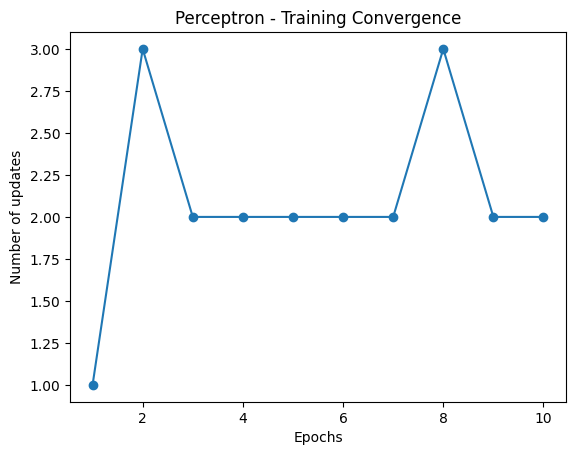

In [47]:
ppn = Perceptron(eta=0.1, n_iter=10)
ppn.fit(X, y)

plt.plot(range(1, len(ppn.errors_) + 1), ppn.errors_, marker='o')
plt.xlabel('Epochs')
plt.ylabel('Number of updates')
plt.title('Perceptron - Training Convergence')
plt.show()

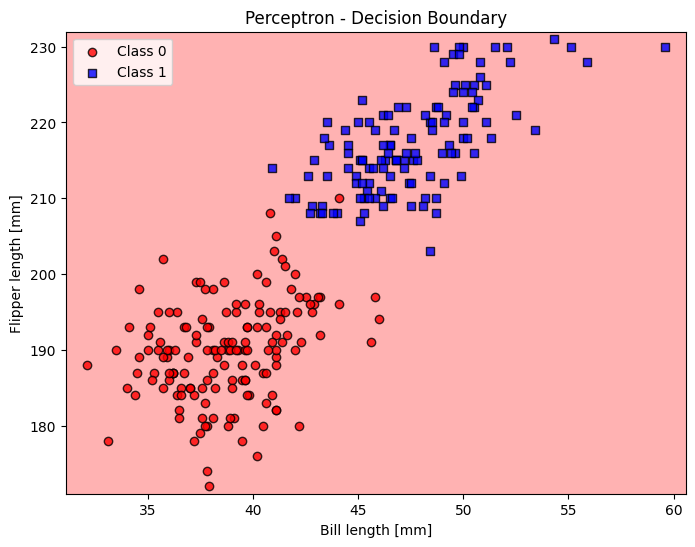

In [48]:
plt.figure(figsize=(8, 6))
plot_decision_regions(X, y, classifier=ppn)

plt.xlabel('Bill length [mm]')
plt.ylabel('Flipper length [mm]')
plt.legend(loc='upper left')
plt.title('Perceptron - Decision Boundary')
plt.show()

## Section 5: Feature Scaling: Standardization


In [49]:
X_std = np.copy(X)
X_std[:,0] = (X[:,0] - X[:,0].mean()) / X[:,0].std()
X_std[:,1] = (X[:,1] - X[:,1].mean()) / X[:,1].std()


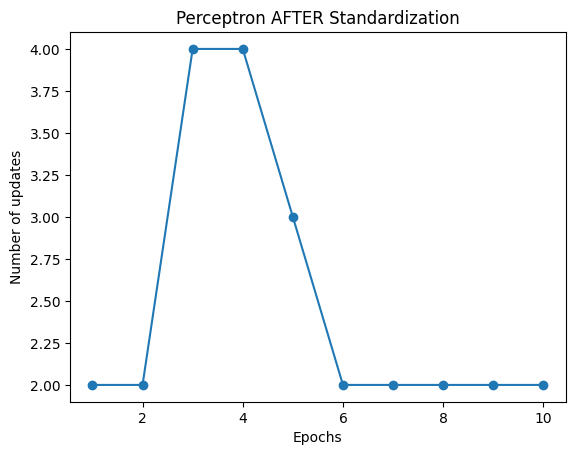

In [50]:
ppn_std = Perceptron(eta=0.1, n_iter=10)
ppn_std.fit(X_std, y)

plt.plot(range(1, len(ppn_std.errors_) + 1), ppn_std.errors_, marker='o')
plt.xlabel('Epochs')
plt.ylabel('Number of updates')
plt.title('Perceptron AFTER Standardization')
plt.show()

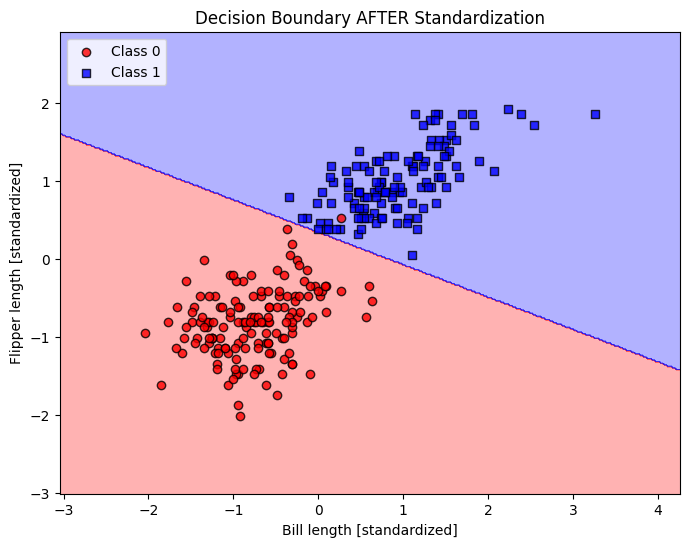

In [51]:
plt.figure(figsize=(8,6))
plot_decision_regions(X_std, y, classifier=ppn_std)
plt.xlabel('Bill length [standardized]')
plt.ylabel('Flipper length [standardized]')
plt.legend(loc='upper left')
plt.title('Decision Boundary AFTER Standardization')
plt.show()

## Section 4: Adaline and Batch Gradient Descent

In [52]:
class AdalineGD:
  def __init__(self, eta=0.01, n_iter=50, random_state=1):
    self.eta = eta
    self.n_iter = n_iter
    self.random_state = random_state

  def fit(self, X, y):
    rgen = np.random.RandomState(self.random_state)
    self.w_ = rgen.normal(loc=0.0, scale=0.01, size=X.shape[1])
    # np.float_ is deprecated. Use float instead.
    self.b_ = float(0.)
    self.losses_ = []

    for  i in range(self.n_iter):
      net_input = self.net_input(X)
      output = self.activation(net_input)
      errors = (y - output)

      self.w_ += self.eta * 2.0 * X.T.dot(errors) / X.shape[0]
      self.b_ += self.eta * 2.0 * errors.mean()
      loss = (errors**2).mean()
      self.losses_.append(loss)

    return self

  def net_input(self,X): return np.dot(X, self.w_) + self.b_

  def activation(self, X): return X

  def predict(self, X):
    return np.where(self.activation(self.net_input(X)) >= 0.5, 1, 0)

In [53]:
# 1. 建立 Adaline 模型 (注意我們是用標準化後的資料 X_std)
ada = AdalineGD(n_iter=20, eta=0.5) # 學習率可以設稍微大一點
ada.fit(X_std, y)

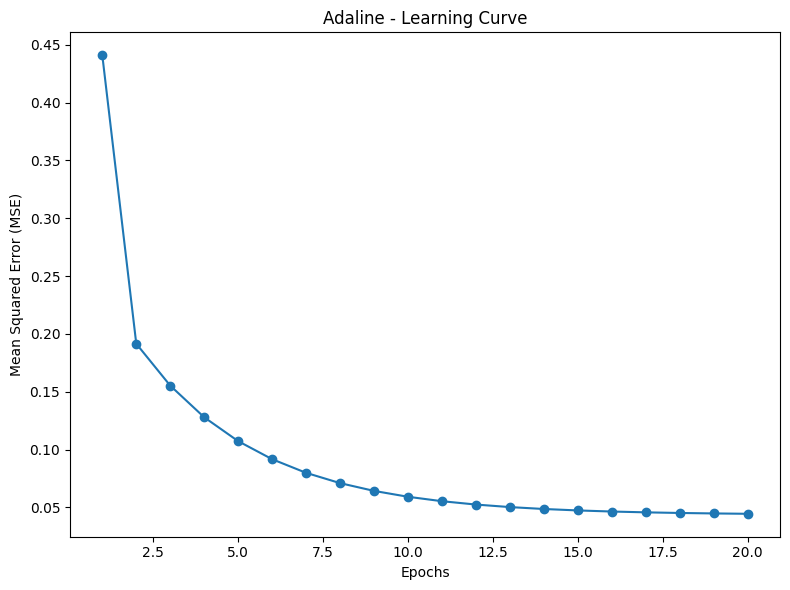

In [54]:
# 2. 畫出 MSE 損失函數下降圖
plt.figure(figsize=(8,6))
plt.plot(range(1, len(ada.losses_) + 1), ada.losses_, marker='o')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Adaline - Learning Curve')
plt.tight_layout()
plt.show()

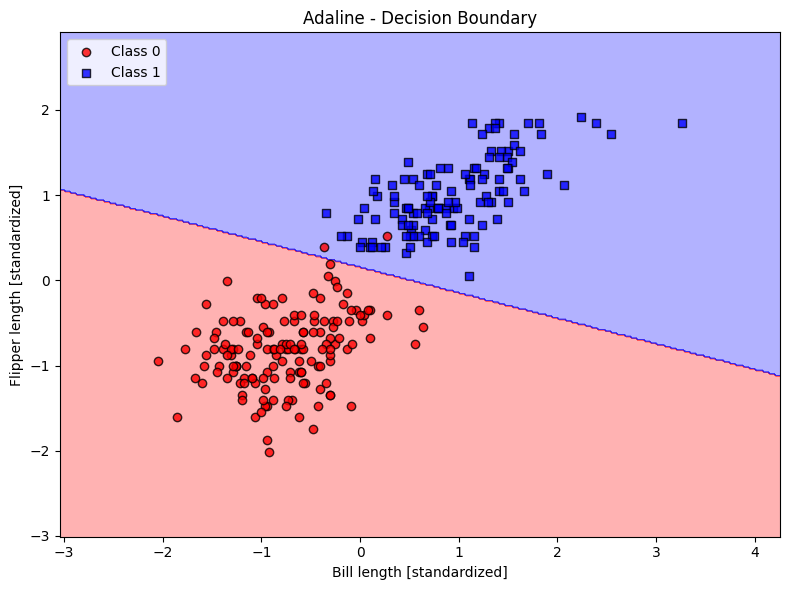

In [55]:
# 3. 畫出 Adaline 的決策邊界
plt.figure(figsize=(8,6))
plot_decision_regions(X_std, y, classifier=ada)
plt.title('Adaline - Decision Boundary')
plt.xlabel('Bill length [standardized]')
plt.ylabel('Flipper length [standardized]')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

## Section 6: Stochastic Gradient Descent (SGD)

In [56]:
def _shuffle(self, X, y):
  r = self.regn.permutation(len(y))
  return X[r], y[r]

def _update_weights(self, xi, target):
  output = self.activation(self.net_input(xi))
  error = (target - output)
  self.w_ += self.eta * 2.0 * xi * error
  self.b_ += self.eta * 2.0 * error
  return error**2
